In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.DataFrame({'Подразделение': ['Каменский СК', 'Осетровский СК','Каменский СК','Осетровский СК','Осетровский СК'],
                   'Падеж': [4, 5, 10, 12, 15]})
df.head()

,Подразделение,Падеж
0,Каменский СК,4
1,Осетровский СК,5
2,Каменский СК,10
3,Осетровский СК,12
4,Осетровский СК,15


In [36]:
df[df['Подразделение'] == 'Осетровский СК']

,Подразделение,Падеж
1,Осетровский СК,5
3,Осетровский СК,12
4,Осетровский СК,15


In [46]:
df.loc[df['Подразделение'] == 'Осетровский СК', 'Подразделение'] = 'Осетровский'

In [48]:
df

,Подразделение,Падеж
0,Каменский СК,4
1,Осетровский,5
2,Каменский СК,10
3,Осетровский,12
4,Осетровский,15


In [55]:
df = pd.DataFrame({'Подразделение': ['Каменский СК', 'Осетровский СК','Бутурлиновский СК','Буравлянский СК','Центральный СК', 'Бобровский СК', 'Таловский СК', 'Каменский СК', 'Осетровский СК','Бутурлиновский СК','Буравлянский СК','Центральный СК', 'Бобровский СК', 'Таловский СК'],
                   'Номенклатура': ['Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин', 'Амоксициллин'],
                   'Количество':[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   'Неделя': [1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2]}
                 )

In [68]:
nom_lst = ['Амоксициллин', 'N1', 'N2']

In [70]:
df_filter = df.query('Номенклатура in @nom_lst')

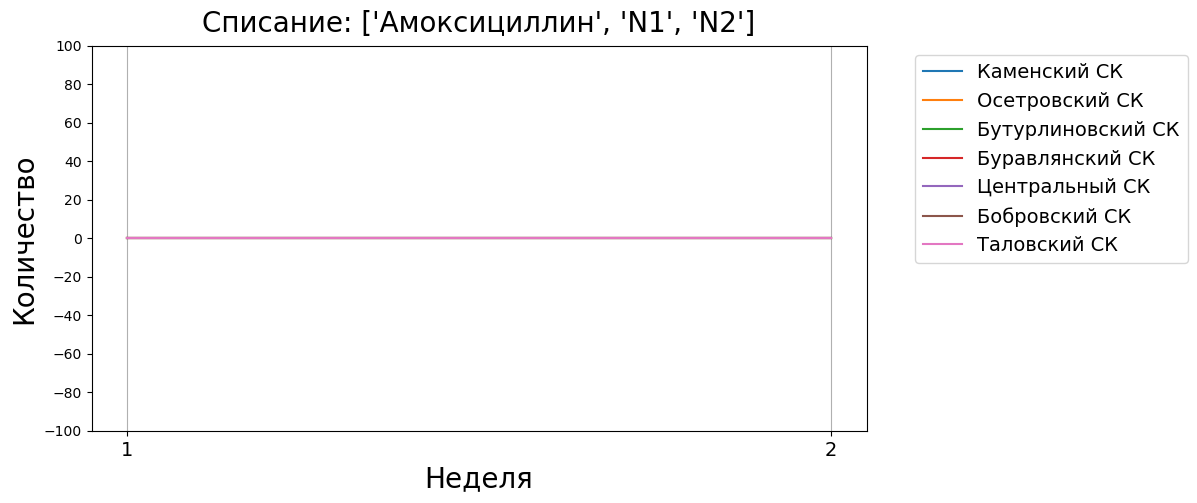

In [160]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(data=df_filter, x='Неделя', y='Количество', hue = 'Подразделение')
ax.set_xlabel('Неделя', fontdict={'fontsize':20})
ax.set_ylabel('Количество', fontdict={'fontsize':20})

ax.set_title(f'Списание: {nom_lst}', fontdict={'fontsize':20, 'color':'black'}, pad=10)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize=14)
ax.grid(which='major', axis='x')

ax.set_xticks(ticks=[1, 2])
ax.tick_params(axis='x', labelsize = 14)
ax.set_yticks(ticks=np.linspace(-100, 100, 11));

In [63]:
pivot_df = df_filter.pivot(index='Подразделение', columns='Неделя', values='Количество')
pivot_df

Неделя,1,2
Подразделение,,
Бобровский СК,0,0
Буравлянский СК,0,0
Бутурлиновский СК,0,0
Каменский СК,0,0
Осетровский СК,0,0
Таловский СК,0,0
Центральный СК,0,0


(array([0.5, 1.5]), [Text(0.5, 0, '1'), Text(1.5, 0, '2')])

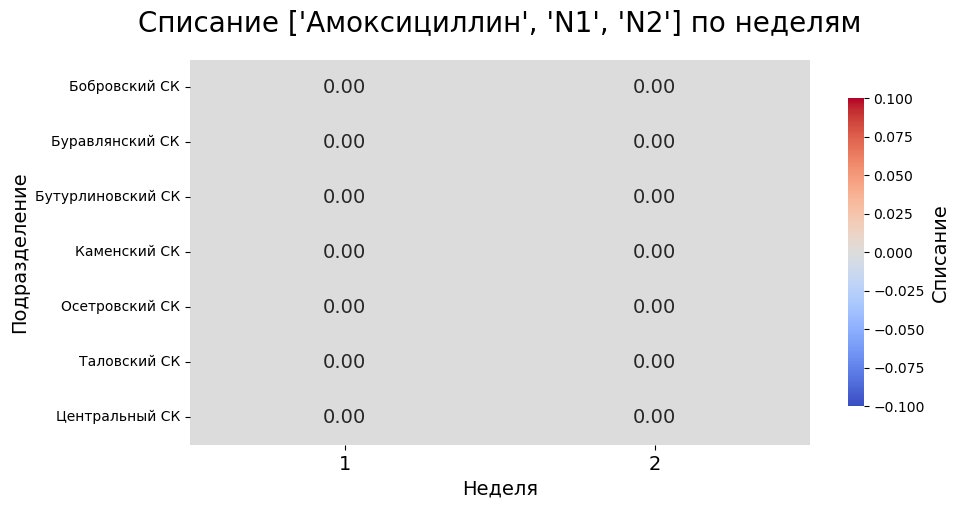

In [178]:
plt.figure(figsize=(10, 5))

ax = sns.heatmap(
        pivot_df, 
        annot=True,      # Пишем значения внутри ячеек
        cmap='coolwarm', # Цветовая гамма (синий-белый-красный)
        fmt=".2f",       # Формат чисел (2 знака после запятой)
        cbar_kws={'label': 'Списание', 'shrink': 0.8},
        annot_kws={'size': 14}  # размер текста в ячейках
    )

cbar = ax.collections[0].colorbar
cbar.set_label('Списание', size=14)  # размер label

plt.xlabel(xlabel='Неделя',fontdict={'fontsize':14})
plt.ylabel(ylabel='Подразделение',fontdict={'fontsize':14})
plt.title(f"Списание {nom_lst} по неделям", pad=20, fontdict={'fontsize':20})
plt.xticks(fontsize=14)

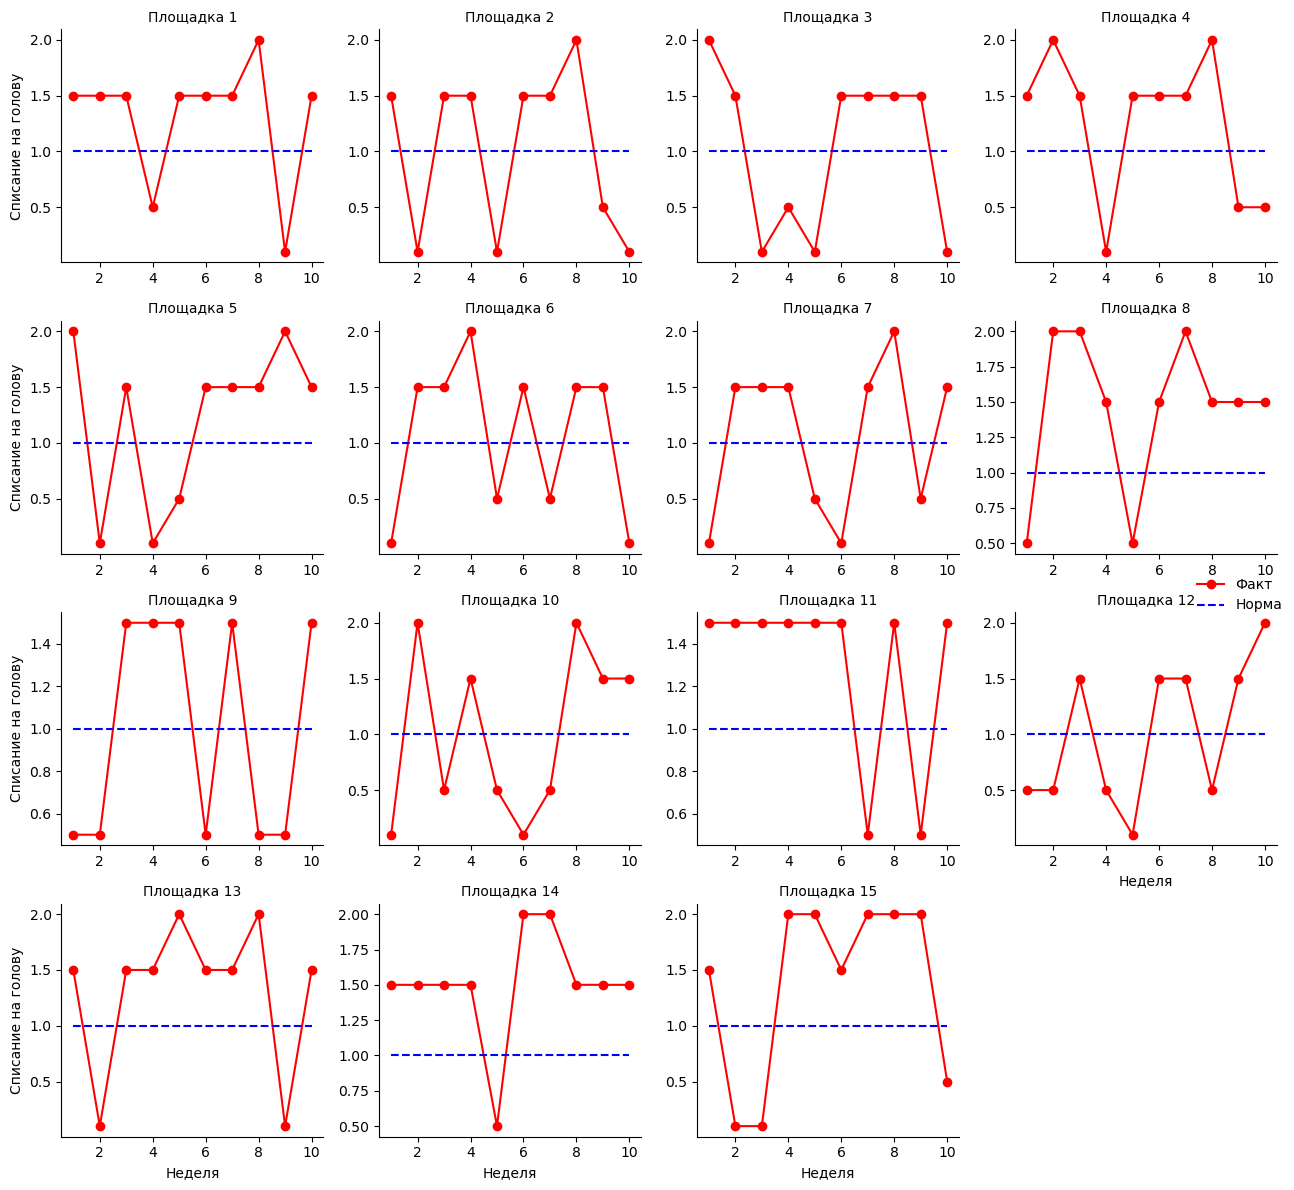

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Создаем пример данных (15 площадок, 10 недель)
np.random.seed(42)
n_weeks = 10
n_sites = 15
weeks = list(range(1, n_weeks + 1))

# Таблица 1: количество животных
data = []
for site in range(1, n_sites + 1):
    for week in weeks:
        animals = np.random.randint(100, 500)  # случайное поголовье
        # Ожидаемое списание = animals (норма), но с искажениями
        actual = animals * np.random.choice([0.1, 0.5, 1.5, 2.0], p=[0.1, 0.2, 0.5, 0.2])
        data.append({
            'site': f'Площадка {site}',
            'week': week,
            'animals': animals,
            'actual_per_animal': actual / animals  # фактическое списание на голову
        })

df = pd.DataFrame(data)

# Добавляем норму (ожидаемое списание на голову = 1)
df['expected_per_animal'] = 1.0

# Фасетный график: отдельная панель для каждой площадки
g = sns.FacetGrid(df, col='site', col_wrap=4,  # 4 колонки в сетке
                  height=3, sharex=True, sharey=True)

# Рисуем факт и норму
g.map(plt.plot, 'week', 'actual_per_animal', marker='o', color='red', label='Факт')
g.map(plt.plot, 'week', 'expected_per_animal', color='blue', linestyle='--', label='Норма')

# Настройка осей и заголовков
g.set_axis_labels('Неделя', 'Списание на голову')
g.set_titles('{col_name}')
g.add_legend()

plt.tight_layout()
plt.show()

In [219]:
df

,site,week,actual_per_animal
0,Площадка 1,1,0.0
1,Площадка 1,2,0.0
2,Площадка 1,3,0.0
3,Площадка 1,4,0.0
4,Площадка 1,5,0.0
...,...,...,...
145,Площадка 15,6,1.0
146,Площадка 15,7,1.0
147,Площадка 15,8,1.0
148,Площадка 15,9,0.0


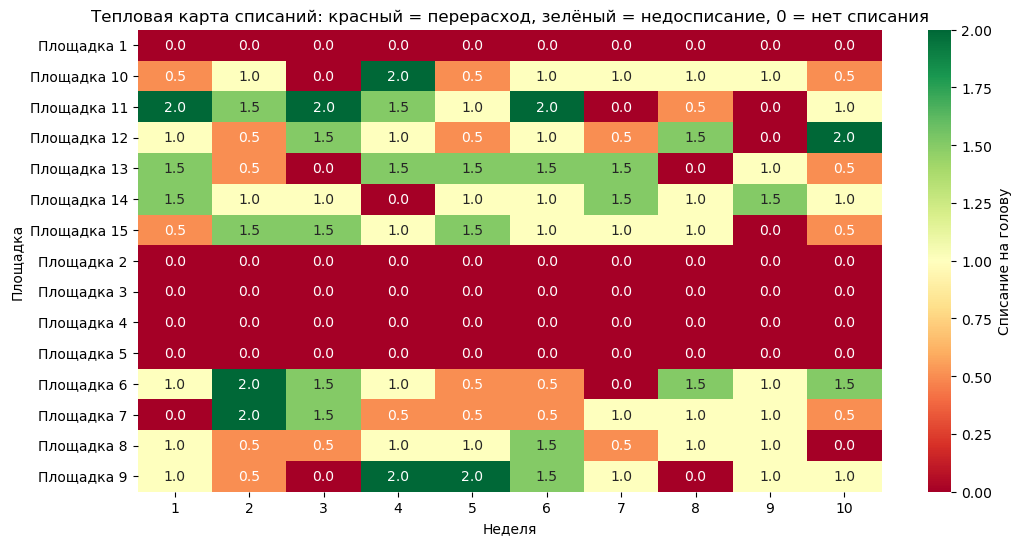

In [200]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Пример: 5 площадок с нулями, 10 с нормальными
np.random.seed(42)
sites = [f'Площадка {i}' for i in range(1, 16)]
weeks = range(1, 11)

data = []
for site in sites:
    for week in weeks:
        if site in ['Площадка 1', 'Площадка 2', 'Площадка 3', 'Площадка 4', 'Площадка 5']:
            actual = 0  # всё время ноль
        else:
            actual = np.random.choice([0, 0.5, 1, 1.5, 2], p=[0.1, 0.2, 0.4, 0.2, 0.1])
        data.append({'site': site, 'week': week, 'actual_per_animal': actual})

df = pd.DataFrame(data)

# Сводная таблица для тепловой карты
pivot = df.pivot(index='site', columns='week', values='actual_per_animal')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=1, 
            cbar_kws={'label': 'Списание на голову'})
plt.title('Тепловая карта списаний: красный = перерасход, зелёный = недосписание, 0 = нет списания')
plt.xlabel('Неделя')
plt.ylabel('Площадка')
plt.show()

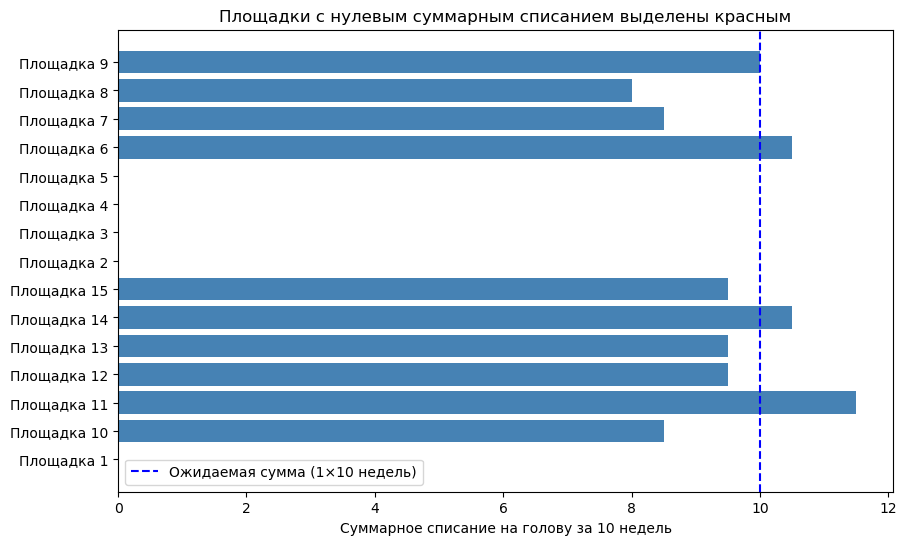

In [202]:
summary = df.groupby('site')['actual_per_animal'].sum().reset_index()

plt.figure(figsize=(10, 6))
colors = ['red' if x == 0 else 'steelblue' for x in summary['actual_per_animal']]
plt.barh(summary['site'], summary['actual_per_animal'], color=colors)
plt.axvline(x=10, color='blue', linestyle='--', label='Ожидаемая сумма (1×10 недель)')
plt.xlabel('Суммарное списание на голову за 10 недель')
plt.title('Площадки с нулевым суммарным списанием выделены красным')
plt.legend()
plt.show()

In [212]:
np.log(350)

5.857933154483459

In [214]:
np.log(10)

2.302585092994046